In [8]:

# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Leitura do Dataset
students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
students_df.columns = students_df.columns.str.strip()


In [3]:

# Separação Coluna Target do Dataset
y = students_df["Target"];
students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)


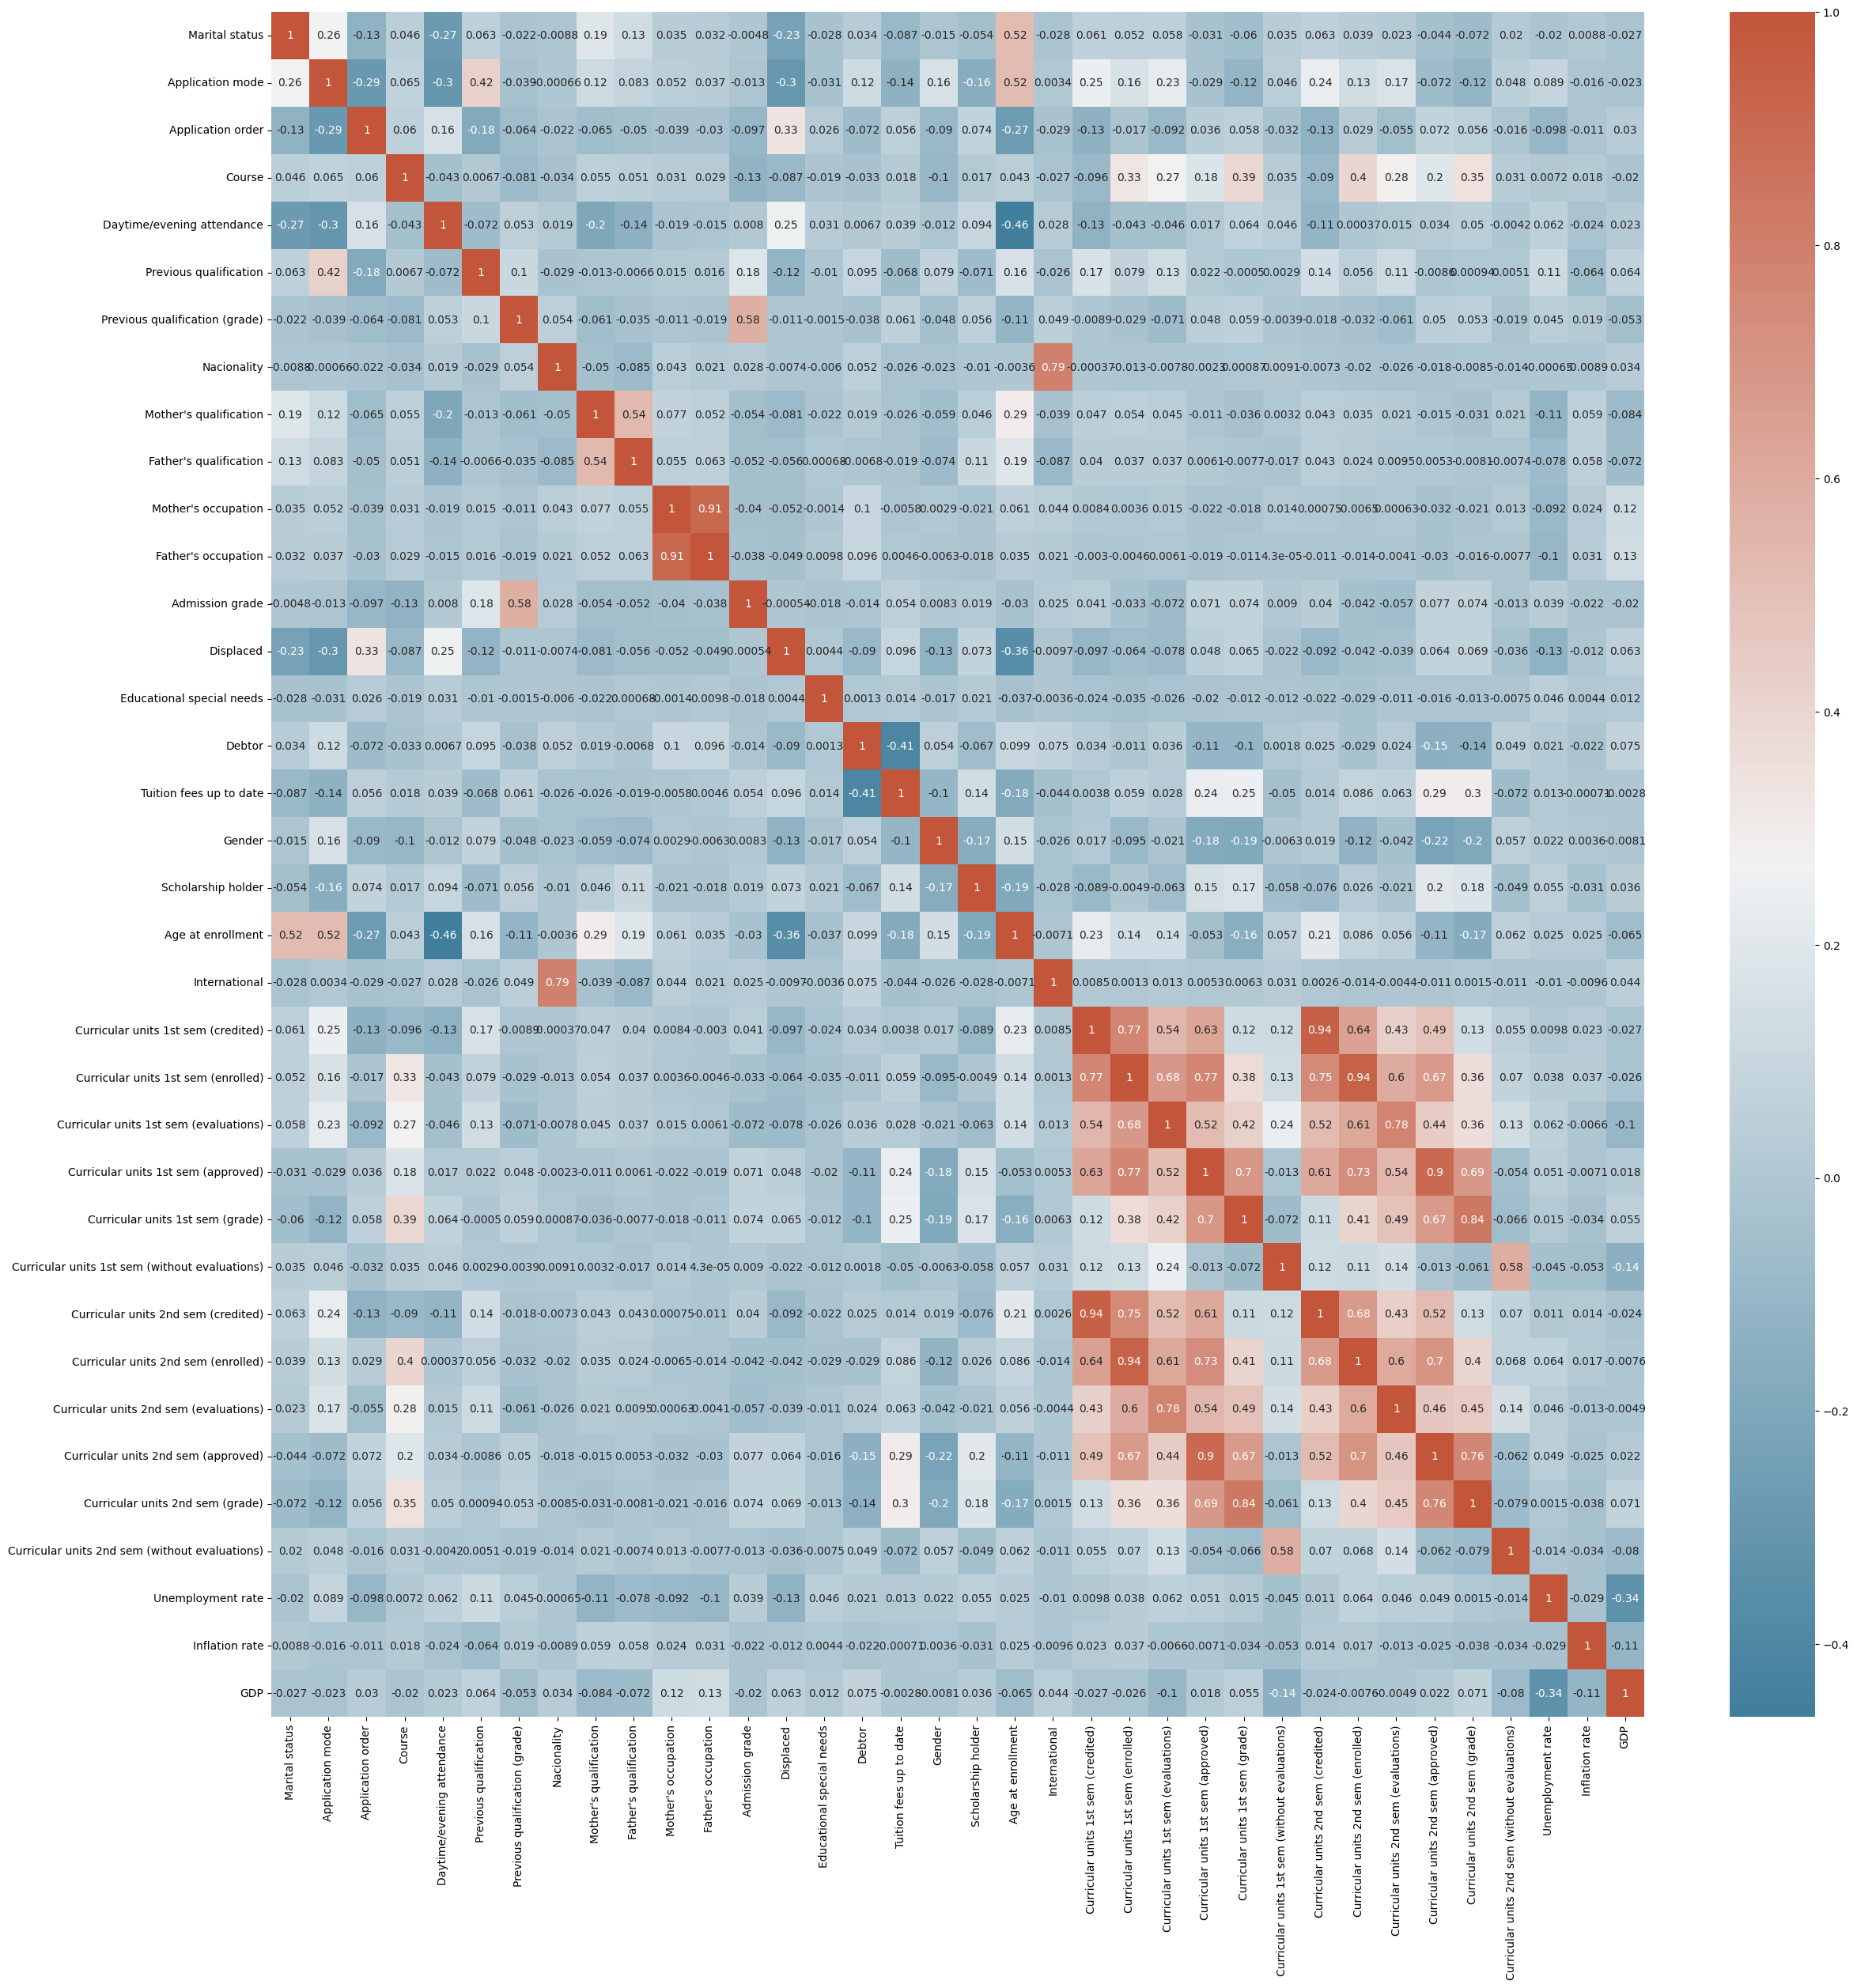

In [4]:

# Matriz de Correlação
correlation_matrix = students_df.corr()
plt.figure(figsize=(28,28))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(correlation_matrix, annot=True, cmap=cmap)
plt.show()


In [5]:

# Metodo de Normalização MinMax
scaler = MinMaxScaler()
scaled_students_df = pd.DataFrame(scaler.fit_transform(students_df), columns = students_df.columns)
scaled_students_df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,0.0,0.285714,0.555556,0.013858,1.0,0.0,0.284211,0.0,0.418605,0.255814,...,0.0,0.0,0.00000,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182
1,0.0,0.250000,0.111111,0.925989,1.0,0.0,0.684211,0.0,0.000000,0.046512,...,0.0,0.0,0.26087,0.181818,0.30,0.735897,0.0,0.732558,0.111111,0.640687
2,0.0,0.000000,0.555556,0.907512,1.0,0.0,0.284211,0.0,0.837209,0.837209,...,0.0,0.0,0.26087,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182
3,0.0,0.285714,0.222222,0.978108,1.0,0.0,0.284211,0.0,0.860465,0.837209,...,0.0,0.0,0.26087,0.303030,0.25,0.667692,0.0,0.209302,0.000000,0.124174
4,0.2,0.678571,0.111111,0.801466,0.0,0.0,0.052632,0.0,0.837209,0.860465,...,0.0,0.0,0.26087,0.181818,0.30,0.700000,0.0,0.732558,0.111111,0.640687


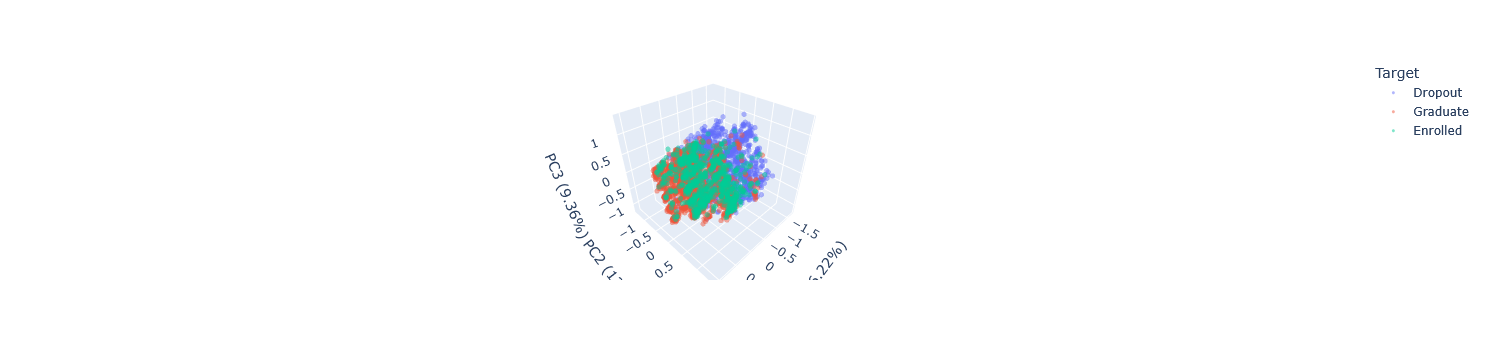

In [6]:

# Aplicação Método PCA para 3 componentes
pca = PCA(n_components = 3)
principalComponents = pca.fit_transform(scaled_students_df)

pca_df = pd.DataFrame(
    data = principalComponents,
    columns = ['principal component 1', 'principal component 2', 'principal component 3'])

graphic_pca_df = pd.concat([pca_df, y.reset_index(drop = True)], axis = 1)

fig = px.scatter_3d(
    graphic_pca_df,
    x = 'principal component 1',
    y = 'principal component 2',
    z = 'principal component 3',
    color = y.name,
    opacity = 0.5,)

fig.update_traces(marker = dict(size = 3))
fig.update_layout(
    scene = dict(
        xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)' ))

fig.show()


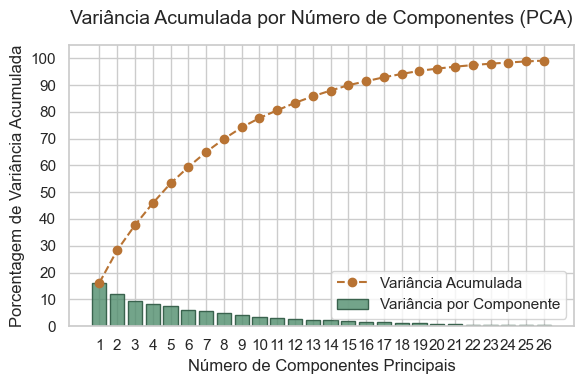

In [33]:
# PCA para o máximo de compoenentes (limite de colunas do dataset)
pca_full = PCA()
pca_full.fit(scaled_students_df)

# cálculo das variâncias em porcentagem
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_) * 100
variancia_individual = pca_full.explained_variance_ratio_ * 100

n_componentes_limite = 26
variancia_acumulada_cortada = variancia_acumulada[:n_componentes_limite]
variancia_individual_cortada = variancia_individual[:n_componentes_limite]

# gráfico com as variâncias acumuladas para descobrir melhor parâmetro de componentes n do PCA
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# plotagem do gráfico de barras para cada variância individual (usando os dados cortados)
plt.bar(
    range(1, n_componentes_limite + 1),
    variancia_individual_cortada,
    color='#508d6dcc',
    edgecolor='#3a634e',
    label='Variância por Componente'
)

# plotagem da linha para variância acumulada do PCA (usando os dados cortados)
plt.plot(
    range(1, n_componentes_limite + 1), 
    variancia_acumulada_cortada, 
    marker='o', 
    linestyle='--', 
    color='#b87333', 
    label='Variância Acumulada'
)

plt.title('Variância Acumulada por Número de Componentes (PCA)', fontsize=14, pad=15)
plt.xlabel('Número de Componentes Principais', fontsize=12)
plt.ylabel('Porcentagem de Variância Acumulada', fontsize=12)
plt.xticks(range(1, n_componentes_limite + 1))
plt.yticks(np.arange(0, 101, step=10))
plt.ylim(0, 105)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()